In [8]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

CHECKPOINT_PATH = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\sam_vit_b_01ec64.pth"
MODEL_TYPE = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=device)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
    )


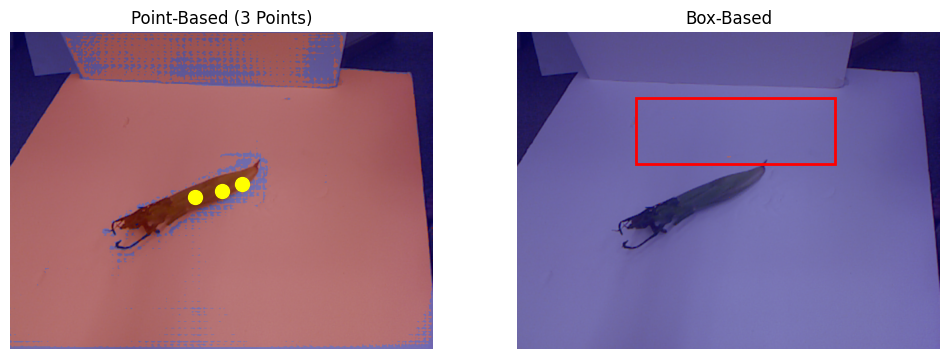

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from segment_anything import sam_model_registry, SamPredictor

CHECKPOINT_PATH = r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\sam_vit_b_01ec64.pth"
MODEL_TYPE = "vit_b"
device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device=device)
predictor = SamPredictor(sam)

image = cv2.imread(r"C:\Users\park2\Desktop\ME592_HW2\robotic-grasping\5_test_images\pcd0805r.png")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image_rgb)

input_points = np.array([[320, 240], [280, 250], [350, 230]]) 
input_labels = np.array([1, 1, 1]) # 1 means 'this is the object'

masks_pts, scores_pts, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True,
)
